In [7]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from option_pricing.black_scholes import (
    bs_call_price,
    bs_put_price,
    bs_call_delta, 
    bs_put_delta, 
    bs_gamma, 
    bs_vega,
    bs_call_theta, 
    bs_put_theta,
    )
from option_pricing.monte_carlo import mc_european_option_price, mc_barrier_option_price
from option_pricing.utils import confidence_interval, convergence_table, estimate_convergence_rate
from ..research.experiments import (
    run_convergence_experiment,
    run_variance_reduction_experiment,
    run_ci_coverage_experiment,
    run_discretisation_bias_experiment,
)

pd.set_option("display.float_format", "{:.5f}".format)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
warnings.filterwarnings('ignore')
print("Environment ready.")

ImportError: attempted relative import with no known parent package

Example of use

In [ ]:
S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20

call_bs = bs_call_price(S0, K, T, r, sigma)
call_bs_delta = bs_call_delta(S0, K, T, r, sigma)
call_theta = bs_call_theta(S0, K, T, r, sigma)
put_bs  = bs_put_price(S0, K, T, r, sigma)
put_bs_delta = bs_put_delta(S0, K, T, r, sigma)
put_theta = bs_put_theta(S0, K, T, r, sigma)
gamma = bs_gamma(S0, K, T, r, sigma)
vega = bs_vega(S0, K, T, r, sigma)

print(f"European call (BS):  {call_bs:.6f}")
print(f"European call delta (BS): {call_bs_delta:.6f}")
print(f"European call theta (BS): {call_theta:.6f}")
print(f"European put  (BS):  {put_bs:.6f}")
print(f"European put delta (BS): {put_bs_delta:.6f}")
print(f"European put theta (BS): {put_theta:.6f}")
print(f"European gamma (BS): {gamma:.6f}")
print(f"European vega (BS): {vega:.6f}")

import math
parity_err = abs(call_bs - put_bs - S0 + K * math.exp(-r * T))
print(f"Put-call parity residual: {parity_err:.2e}")

European call (BS):  10.450584
European call delta (BS): 0.636831
European call theta (BS): -0.025452
European put  (BS):  5.573526
European put delta (BS): -0.363169
European put theta (BS): -0.006579
European gamma (BS): 0.018762
European vega (BS): 0.375240
Put-call parity residual: 0.00e+00


---
## Experiment 1 — Option Prices and Greek Profiles vs Spot


We begin by examining the analytical Black-Scholes Greeks across a range of spot prices for a standard ATM European option (K = 100, T = 1 year, r = 5%, σ = 20%). These profiles serve as the benchmark against which all Monte Carlo estimates will be validated in subsequent sections. Understanding the shapes — particularly where each Greek is largest and where it changes fastest — is essential for interpreting the convergence results that follow.



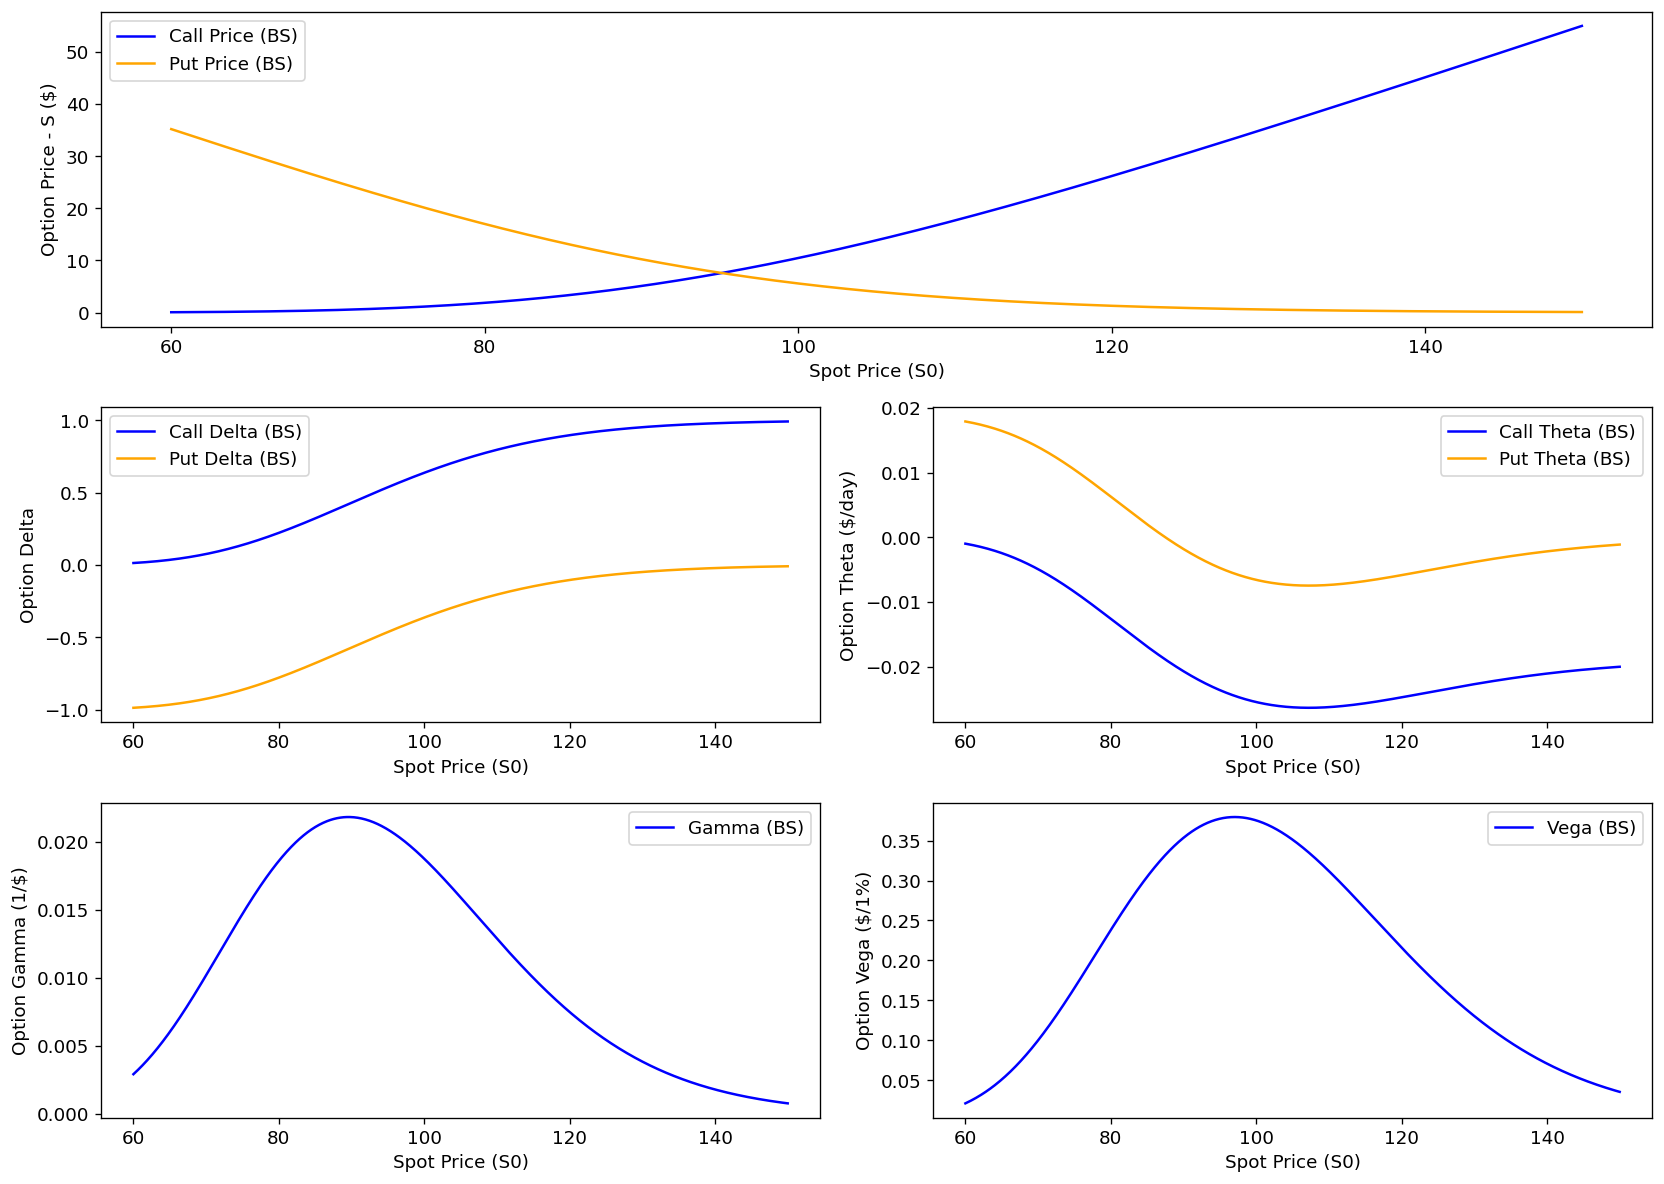

In [ ]:
S0_vector = np.linspace(60, 150, 1001)
K, T, r, sigma = 100.0, 1.0, 0.05, 0.20

call_bs_vector = np.array([bs_call_price(s0_value, K, T, r, sigma) for s0_value in S0_vector])
call_bs_delta_vector = np.array([bs_call_delta(s0_value, K, T, r, sigma) for s0_value in S0_vector])
call_bs_theta_vector = np.array([bs_call_theta(s0_value, K, T, r, sigma) for s0_value in S0_vector])
put_bs_vector  = np.array([bs_put_price(s0_value, K, T, r, sigma) for s0_value in S0_vector])
put_bs_delta_vector = np.array([bs_put_delta(s0_value, K, T, r, sigma) for s0_value in S0_vector])
put_bs_theta_vector = np.array([bs_put_theta(s0_value, K, T, r, sigma) for s0_value in S0_vector])
gamma_bs_vector = np.array([bs_gamma(s0_value, K, T, r, sigma) for s0_value in S0_vector])
vega_bs_vector = np.array([bs_vega(s0_value, K, T, r, sigma) for s0_value in S0_vector])

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

gs = axes[0, 0].get_gridspec()
# remove the underlying Axes
for ax in axes[0, 0:2]:
    ax.remove()
axcenter = fig.add_subplot(gs[0, 0:2])

axcenter.plot(S0_vector, call_bs_vector, label="Call Price (BS)", color="blue")
axcenter.plot(S0_vector, put_bs_vector, label="Put Price (BS)", color="orange")

axcenter.set_xlabel("Spot Price (S0)")
axcenter.set_ylabel("Option Price - S ($)")
axcenter.legend()

axes[1, 0].plot(S0_vector, call_bs_delta_vector, label="Call Delta (BS)", color="blue")
axes[1, 0].plot(S0_vector, put_bs_delta_vector, label="Put Delta (BS)", color="orange")

axes[1, 0].set_xlabel("Spot Price (S0)")
axes[1, 0].set_ylabel("Option Delta")
axes[1, 0].legend()

axes[1, 1].plot(S0_vector, call_bs_theta_vector, label="Call Theta (BS)", color="blue")
axes[1, 1].plot(S0_vector, put_bs_theta_vector, label="Put Theta (BS)", color="orange")
axes[1, 1].set_xlabel("Spot Price (S0)")
axes[1, 1].set_ylabel("Option Theta ($/day)")
axes[1, 1].legend()

axes[2, 0].plot(S0_vector, gamma_bs_vector, label="Gamma (BS)", color="blue")
axes[2, 0].set_xlabel("Spot Price (S0)")
axes[2, 0].set_ylabel("Option Gamma (1/$)")
axes[2, 0].legend()

axes[2, 1].plot(S0_vector, vega_bs_vector, label="Vega (BS)", color="blue")
axes[2, 1].set_xlabel("Spot Price (S0)")
axes[2, 1].set_ylabel("Option Vega ($/1%)")
axes[2, 1].legend()


plt.tight_layout()
plt.show()

**Prices**: Call and put prices are convex functions of spot. They meet near ATM where both have positive value. Deep OTM options approach zero; deep ITM options approach their intrinsic value. The convexity visible here is what Gamma measures.

**Delta**: Call Delta transitions smoothly from 0 (deep OTM) to 1 (deep ITM), passing through approximately 0.5 at ATM. Put Delta mirrors this from −1 to 0. The transition is steepest at ATM — meaning Delta changes fastest there per unit move in spot. This is the region where dynamic hedging requires the most frequent rebalancing.

**Theta**: Both call and put Theta are most negative at ATM, where time value is largest and therefore decays fastest. Deep ITM and OTM options have little time value left to lose, so Theta is close to zero there. Note that call and put Theta are nearly identical in this parameter regime — this follows from put-call parity.

**Gamma**: Gamma is identical for calls and puts (this is exact, not approximate) and peaks sharply at ATM. This has a direct implication for Monte Carlo estimation: the region where Gamma is largest is precisely where finite-difference estimation is hardest, because the second derivative amplifies any noise in the bumped price evaluations. This motivates the convergence analysis in Section 2.

**Vega**: Vega has the same bell shape as Gamma and is also identical for calls and puts. It peaks at ATM, meaning ATM options are the most sensitive to changes in implied volatility. A trader who is long an ATM option profits from a vol spike; one who is short loses. This plot is the visual foundation for understanding vega hedging.

These profiles define the landscape for the MC convergence study. The ATM point (S0 = 100) is where Greek estimation is most demanding — Gamma and Vega are at their maximum, and Delta is changing fastest. All subsequent MC experiments use ATM parameters precisely because this represents the hardest case.

---
## Experiment 2 — Option Prices and Greek Profiles vs Time Maturity

With spot fixed at ATM (S0 = K = 100), we now examine how each Greek evolves as time to expiry T decreases from 2 years to a single trading day (1/252). This perspective is essential for understanding the risks that build up as an option approaches expiration — risks that are invisible when looking at a fixed-maturity snapshot.

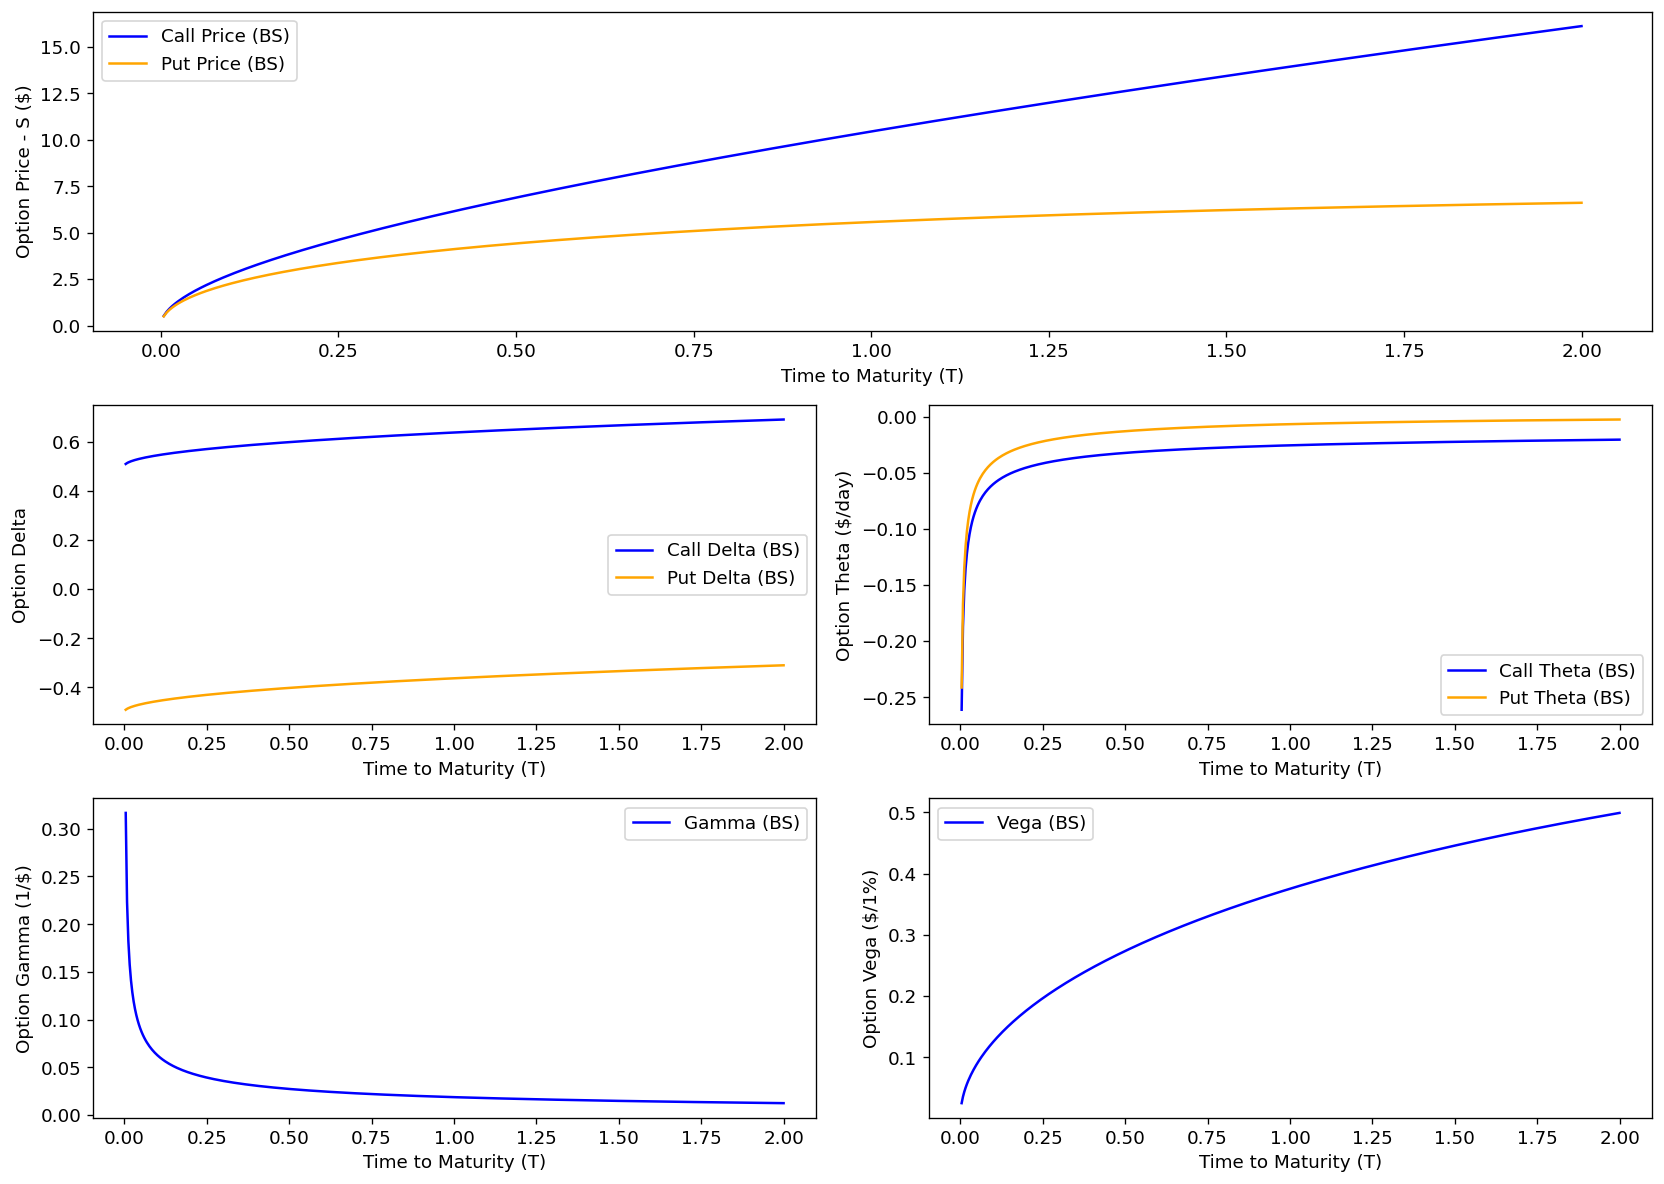

In [ ]:
S0    = 100.0   # ATM spot
K     = 100.0   # strike
r     = 0.05    # 5% risk-free rate
sigma = 0.20    # 20% vol
T_vector = np.linspace(2.0, 1/252, 500)  # T varies


call_bs_vector = np.array([bs_call_price(S0, K, T, r, sigma) for T in T_vector])
call_bs_delta_vector = np.array([bs_call_delta(S0, K, T, r, sigma) for T in T_vector])
call_bs_theta_vector = np.array([bs_call_theta(S0, K, T, r, sigma) for T in T_vector])
put_bs_vector  = np.array([bs_put_price(S0, K, T, r, sigma) for T in T_vector])
put_bs_delta_vector = np.array([bs_put_delta(S0, K, T, r, sigma) for T in T_vector])
put_bs_theta_vector = np.array([bs_put_theta(S0, K, T, r, sigma) for T in T_vector])
gamma_bs_vector = np.array([bs_gamma(S0, K, T, r, sigma) for T in T_vector])
vega_bs_vector = np.array([bs_vega(S0, K, T, r, sigma) for T in T_vector])

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

gs = axes[0, 0].get_gridspec()
# remove the underlying Axes
for ax in axes[0, 0:2]:
    ax.remove()
axcenter = fig.add_subplot(gs[0, 0:2])

axcenter.plot(T_vector, call_bs_vector, label="Call Price (BS)", color="blue")
axcenter.plot(T_vector, put_bs_vector, label="Put Price (BS)", color="orange")

axcenter.set_xlabel("Time to Maturity (T)")
axcenter.set_ylabel("Option Price - S ($)")
axcenter.legend()

axes[1, 0].plot(T_vector, call_bs_delta_vector, label="Call Delta (BS)", color="blue")
axes[1, 0].plot(T_vector, put_bs_delta_vector, label="Put Delta (BS)", color="orange")

axes[1, 0].set_xlabel("Time to Maturity (T)")
axes[1, 0].set_ylabel("Option Delta")
axes[1, 0].legend()

axes[1, 1].plot(T_vector, call_bs_theta_vector, label="Call Theta (BS)", color="blue")
axes[1, 1].plot(T_vector, put_bs_theta_vector, label="Put Theta (BS)", color="orange")
axes[1, 1].set_xlabel("Time to Maturity (T)")
axes[1, 1].set_ylabel("Option Theta ($/day)")
axes[1, 1].legend()

axes[2, 0].plot(T_vector, gamma_bs_vector, label="Gamma (BS)", color="blue")
axes[2, 0].set_xlabel("Time to Maturity (T)")
axes[2, 0].set_ylabel("Option Gamma (1/$)")
axes[2, 0].legend()

axes[2, 1].plot(T_vector, vega_bs_vector, label="Vega (BS)", color="blue")
axes[2, 1].set_xlabel("Time to Maturity (T)")
axes[2, 1].set_ylabel("Option Vega ($/1%)")
axes[2, 1].legend()


plt.tight_layout()
plt.show()

**Prices**: Both call and put prices increase with T, growing roughly as √T. More time means more opportunity for the underlying to move favorably, so options are always worth more with longer maturity. The call grows faster than the put due to the interest rate effect — longer maturity increases the present-value benefit of deferring the strike payment.

**Delta**: Call Delta rises from approximately 0.5 at T→0 to 0.67 at T=2 years. This is because d1 = (r + σ²/2)√T/σ increases with T, pushing N(d1) above 0.5. The ATM call becomes increasingly in-the-money in a risk-neutral sense as maturity lengthens. Put Delta mirrors this from −0.5 toward −0.33. Of the four Greeks, Delta is the most stable across maturities.

**Theta**: Theta explodes negatively as T→0, reaching approximately −$0.25 per day at expiry. This is the "last day" problem — an ATM option that expires tomorrow will lose almost all its remaining time value in 24 hours. As T increases, Theta flattens toward zero: a 2-year option loses very little value per day because the daily time decay is spread over 500+ remaining trading days.

**Gamma**: Gamma diverges as T→0, proportional to 1/√T for an ATM option. A near-expiry ATM option has almost infinite curvature — a $1 move in spot can completely flip whether it expires in- or out-of-the-money. This is why option sellers face "pin risk" at expiry: Gamma is unmanageably large precisely when the position is closest to resolution. As T increases, Gamma decays smoothly toward zero.

**Vega**: Vega behaves oppositely to Gamma — it collapses toward zero as T→0 and grows as T increases. An option expiring tomorrow has almost no sensitivity to implied volatility because there is no time left for volatility to affect the outcome. Longer-dated options are the primary vehicle for vol trading precisely because their Vega is large.

The most important relationship visible in this plot is between Gamma and Theta. They move together: when Gamma is large and positive (near expiry), Theta is large and negative. This is not a coincidence — it is enforced by the Black-Scholes PDE. For a Delta-neutral position: Theta ≈ −½ σ² S² Gamma. You cannot have the convexity benefit of high Gamma without paying the daily time decay of negative Theta. This tradeoff is the central tension in options trading and risk management.


In [ ]:
df_disc = run_discretisation_bias_experiment(
    S0=S0, K=K, barrier=120.0, T=T, r=r, sigma=sigma,
    step_grid=[2, 4, 8, 16, 32, 64, 128, 252, 504],
    n_paths=100_000,
    antithetic=True,
    random_seed=42,
)
df_disc[["n_steps", "dt", "mc_price", "std_error", "ci_lower", "ci_upper", "runtime_s", "bias_vs_finest"]].rename(columns={
    "std_error": "SE", "ci_lower": "CI lower", "ci_upper": "CI upper",
    "runtime_s": "runtime (s)", "bias_vs_finest": "bias vs n=504",
})